In [ ]:
# Anomaly Detection on 3W Dataset using IQR

This notebook evaluates the **3W oil well dataset** using a statistical
**Interquartile Range (IQR)** anomaly detection approach.

The objective is to:
- Apply anomaly detection on labeled 3W data
- Evaluate performance using standard metrics
- Compare sensors
- Identify the best-performing configuration

This work fulfills **Task #117: Anomaly Detection and Evaluation of 3W Dataset**.


In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve

from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix
)

sns.set_style("whitegrid")


In [ ]:
PARQUET_PATH = "path to .parquet file"

df = pd.read_parquet(PARQUET_PATH)

print("Rows:", len(df))
df.head()


Rows: 40085284


,timestamp,P-PDG,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,T-JUS-CKGL,QGL,class,scenario_id,well_file,is_fault
0,2013-11-04 01:41:01,0.0,18852350.0,116.7782,9599435.0,173.0961,2902859.0,NaN,0.0,0.0,2,WELL-00002_20131104014101.csv,0
1,2013-11-04 01:41:02,0.0,18852350.0,116.7781,9599434.0,173.0961,2902867.0,NaN,0.0,0.0,2,WELL-00002_20131104014101.csv,0
2,2013-11-04 01:41:03,0.0,18852350.0,116.7780,9599432.0,173.0961,2902875.0,NaN,0.0,0.0,2,WELL-00002_20131104014101.csv,0
3,2013-11-04 01:41:04,0.0,18852350.0,116.7779,9599431.0,173.0961,2902882.0,NaN,0.0,0.0,2,WELL-00002_20131104014101.csv,0
4,2013-11-04 01:41:05,0.0,18852350.0,116.7779,9599429.0,173.0961,2902890.0,NaN,0.0,0.0,2,WELL-00002_20131104014101.csv,0


In [3]:
df["class"].value_counts().sort_index()


class
0.0      11124891
1.0       2905974
2.0        362199
3.0       4834089
4.0       2462141
5.0      10550253
101.0     5278494
102.0      146237
105.0     2421006
Name: count, dtype: int64

In [4]:
def iqr_detect(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - k * iqr
    upper = q3 + k * iqr

    return ((series < lower) | (series > upper)).astype(int)


In [5]:
SENSORS = [
    "P-PDG",
    "P-TPT",
    "T-TPT",
    "P-MON-CKP",
    "T-JUS-CKP",
    "P-JUS-CKGL",
    "QGL",
]


In [6]:
results = []

for sensor in SENSORS:
    y_true = df["is_fault"].values
    y_pred = iqr_detect(df[sensor])

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )

    results.append({
        "sensor": sensor,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

results_df = pd.DataFrame(results)
results_df


,sensor,precision,recall,f1
0,P-PDG,0.567753,3.368048e-04,6.732103e-04
1,P-TPT,0.835096,1.632499e-02,3.202395e-02
2,T-TPT,0.987102,7.000209e-02,1.307330e-01
3,P-MON-CKP,0.297765,4.944246e-02,8.480367e-02
4,T-JUS-CKP,0.959180,1.328265e-01,2.333402e-01
5,P-JUS-CKGL,0.000000,0.000000e+00,0.000000e+00
6,QGL,1.000000,2.417094e-07,4.834187e-07


In [7]:
best = results_df.sort_values("f1", ascending=False).iloc[0]
best


sensor       T-JUS-CKP
precision      0.95918
recall        0.132827
f1             0.23334
Name: 4, dtype: object

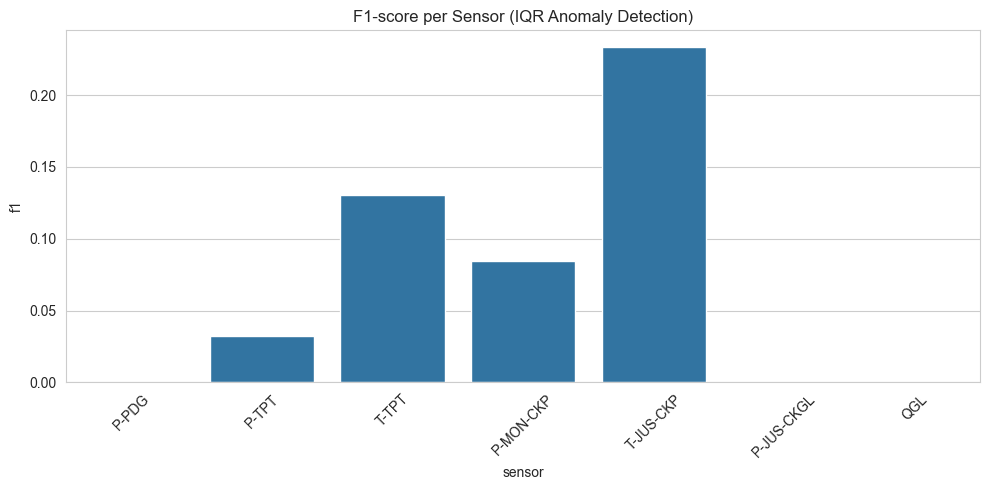

In [8]:
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="sensor", y="f1")
plt.title("F1-score per Sensor (IQR Anomaly Detection)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/Users/starbook/.pyenv/versions/3.13.0/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


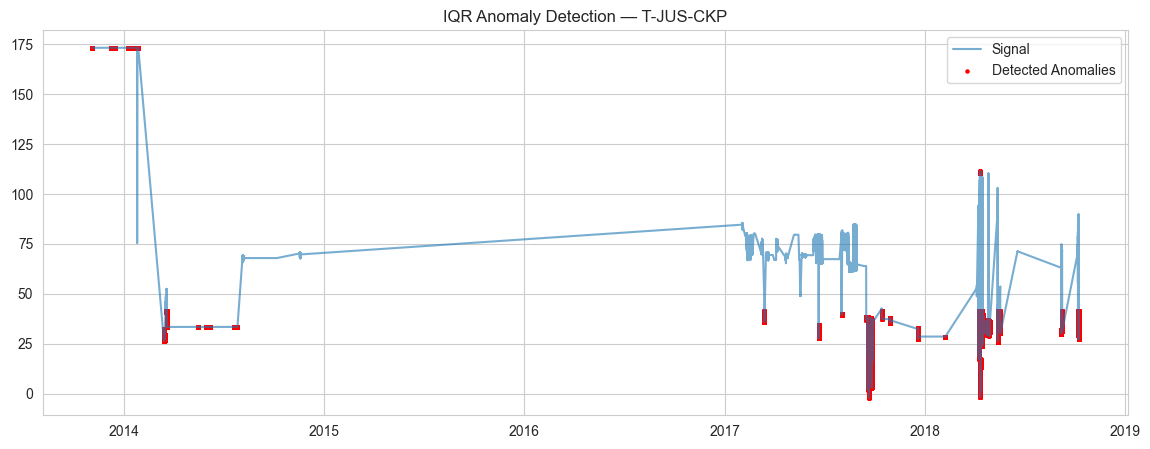

In [9]:

sensor = best["sensor"]

df["is_anomaly"] = iqr_detect(df[sensor])

plt.figure(figsize=(14,5))
plt.plot(df["timestamp"], df[sensor], label="Signal", alpha=0.6)
plt.scatter(
    df.loc[df["is_anomaly"] == 1, "timestamp"],
    df.loc[df["is_anomaly"] == 1, sensor],
    color="red", s=5, label="Detected Anomalies"
)
plt.title(f"IQR Anomaly Detection — {sensor}")
plt.legend()
plt.show()


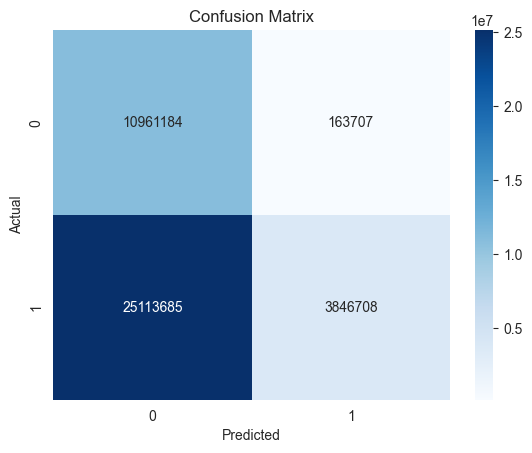

In [10]:
cm = confusion_matrix(df["is_fault"], df["is_anomaly"])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



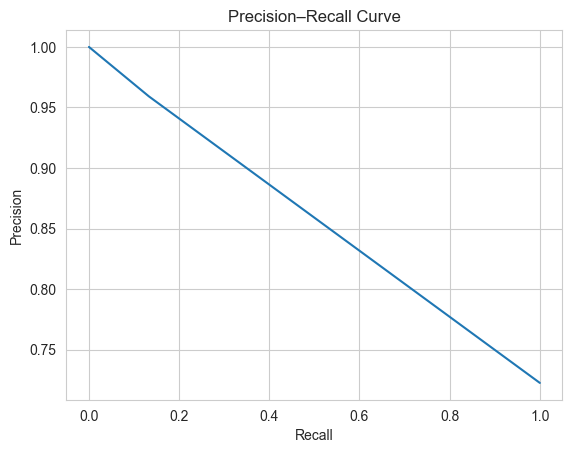

In [13]:

precision, recall, _ = precision_recall_curve(
    df["is_fault"], df["is_anomaly"]
)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()
